In [9]:
import itertools
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

weekly = (
    pd.read_csv("data/processed/weekly_load.csv", index_col=0, parse_dates=True)
      .squeeze("columns")      # DataFrame -> Series
)
weekly = weekly.asfreq("W")    # restore the weekly frequency on the index

TEST_WEEKS = 104
SEASONALITY = 52
DEFAULT_SEASONAL_ORDER = (0, 1, 1, 52)   # airline-style seasonal component

In [10]:
# ----------------------------------------------------------------------
# 0. Split
# ----------------------------------------------------------------------

def train_test_split(weekly: pd.Series, test_weeks: int = TEST_WEEKS):
    return weekly.iloc[:-test_weeks], weekly.iloc[-test_weeks:]

In [11]:
# ----------------------------------------------------------------------
# 1. AIC grid search over non-seasonal orders
# ----------------------------------------------------------------------

def _fit_one(y, order, seasonal_order):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return SARIMAX(
            y, order=order, seasonal_order=seasonal_order,
            enforce_stationarity=False, enforce_invertibility=False,
        ).fit(disp=False)


def sarima_grid_search(
    y_train: pd.Series,
    p_range=range(0, 7),
    d_range=range(0, 3),
    q_range=range(0, 7),
    seasonal_order=DEFAULT_SEASONAL_ORDER,
    verbose=True,
) -> pd.DataFrame:
    """
    Fit every (p,d,q) combination with the fixed seasonal_order and record AIC.
    Non-convergent / invalid combinations are kept with AIC = NaN so you can
    see what was tried. Returns a DataFrame sorted by AIC (best first).
    """
    combos = list(itertools.product(p_range, d_range, q_range))
    rows = []
    for i, (p, d, q) in enumerate(combos, 1):
        try:
            fit = _fit_one(y_train, (p, d, q), seasonal_order)
            aic, bic = fit.aic, fit.bic
            ok = np.isfinite(aic)
        except Exception:
            aic, bic, ok = np.nan, np.nan, False
        rows.append({"order": (p, d, q), "p": p, "d": d, "q": q,
                     "aic": aic, "bic": bic})
        if verbose and (i % 10 == 0 or i == len(combos)):
            best = np.nanmin([r["aic"] for r in rows])
            print(f"  {i:3d}/{len(combos)} fitted | best AIC so far: {best:.1f}")

    df = pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)
    return df


def compare_seasonal_orders(y_train, order, candidates=None) -> pd.DataFrame:
    """Small side-comparison of seasonal orders for a fixed (p,d,q)."""
    if candidates is None:
        candidates = [(0, 1, 1, 52), (1, 1, 0, 52), (1, 1, 1, 52), (0, 1, 0, 52)]
    rows = []
    for so in candidates:
        try:
            fit = _fit_one(y_train, order, so)
            rows.append({"seasonal_order": so, "aic": fit.aic, "bic": fit.bic})
        except Exception:
            rows.append({"seasonal_order": so, "aic": np.nan, "bic": np.nan})
    return pd.DataFrame(rows).sort_values("aic").reset_index(drop=True)


def fit_sarima(y_train, order, seasonal_order=DEFAULT_SEASONAL_ORDER):
    return _fit_one(y_train, order, seasonal_order)

In [12]:
# ----------------------------------------------------------------------
# 2. Residual diagnostics
# ----------------------------------------------------------------------

def residual_diagnostics(fit, lags=52, burn=SEASONALITY, path=None):
    """
    Assess model fit through the residuals:
      * residual ACF (should look like white noise -- no significant spikes),
      * residual distribution (histogram + QQ plot, should be ~Normal),
      * Ljung-Box test (H0: residuals are independent; want p > 0.05).

    The first `burn` residuals are dropped: seasonal differencing (D=1, s=52)
    produces a large diffuse-initialisation transient that is not informative.
    """
    resid = pd.Series(fit.resid).iloc[burn:]

    fig, ax = plt.subplots(2, 2, figsize=(13, 9))

    # (a) residuals over time
    ax[0, 0].plot(resid.index, resid.values, lw=0.8)
    ax[0, 0].axhline(0, color="k", lw=0.6)
    ax[0, 0].set_title("Residuals over time")

    # (b) residual ACF
    plot_acf(resid, lags=lags, ax=ax[0, 1])
    ax[0, 1].set_title("Residual ACF")

    # (c) histogram + normal curve
    ax[1, 0].hist(resid, bins=25, density=True, alpha=0.6, color="tab:blue")
    xs = np.linspace(resid.min(), resid.max(), 200)
    ax[1, 0].plot(xs, stats.norm.pdf(xs, resid.mean(), resid.std()),
                  "r-", lw=1.5, label="Normal fit")
    ax[1, 0].set_title("Residual distribution")
    ax[1, 0].legend()

    # (d) QQ plot
    stats.probplot(resid, dist="norm", plot=ax[1, 1])
    ax[1, 1].set_title("Residual QQ plot")

    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")

    lb = acorr_ljungbox(resid, lags=[12, 24, 52], return_df=True)
    jb_stat, jb_p = stats.jarque_bera(resid)[:2]
    summary = {
        "resid_mean": float(resid.mean()),
        "resid_std": float(resid.std()),
        "ljung_box": lb,                       # DataFrame of lb_stat / lb_pvalue
        "jarque_bera_stat": float(jb_stat),
        "jarque_bera_p": float(jb_p),
    }
    return summary, fig

In [13]:
# ----------------------------------------------------------------------
# 3. Forecast with confidence intervals
# ----------------------------------------------------------------------

def forecast_sarima(fit, steps, index, alpha=0.05):
    """Return point forecast and (1-alpha) confidence interval as a DataFrame."""
    fc = fit.get_forecast(steps=steps)
    mean = fc.predicted_mean
    ci = fc.conf_int(alpha=alpha)
    mean.index = index
    ci.index = index
    ci.columns = ["lower", "upper"]
    return mean, ci


def plot_forecast(train, test, mean, ci, path=None):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(train.index, train, color="tab:gray", lw=1, label="Train")
    ax.plot(test.index, test, color="black", lw=2, label="Test (actual)")
    ax.plot(mean.index, mean, color="tab:red", lw=1.8, label="SARIMA forecast")
    ax.fill_between(ci.index, ci["lower"], ci["upper"],
                    color="tab:red", alpha=0.15, label="95% CI")
    ax.axvline(test.index[0], color="k", lw=0.8, alpha=0.4)
    ax.set_title("SARIMA forecast -- weekly German load, 2-year horizon")
    ax.set_ylabel("Load (GW)")
    ax.set_xlabel("Date")
    ax.legend(ncol=2, fontsize=9)
    fig.tight_layout()
    if path:
        fig.savefig(path, dpi=150, bbox_inches="tight")
    return fig

In [14]:
# ----------------------------------------------------------------------
# 4. Evaluation
# ----------------------------------------------------------------------

def evaluate(name, y_true, y_pred, y_train, seasonality=SEASONALITY):
    y_pred = y_pred.reindex(y_true.index)
    err = y_pred.to_numpy() - y_true.to_numpy()
    yt = y_train.to_numpy()
    scale = np.mean(np.abs(yt[seasonality:] - yt[:-seasonality]))
    return {
        "model": name,
        "MAE": float(np.mean(np.abs(err))),
        "RMSE": float(np.sqrt(np.mean(err ** 2))),
        "MASE": float(np.mean(np.abs(err)) / scale),
        "Bias": float(np.mean(err)),
    }


def coverage(ci, y_true):
    inside = (y_true.to_numpy() >= ci["lower"].to_numpy()) & \
             (y_true.to_numpy() <= ci["upper"].to_numpy())
    return float(inside.mean())

In [15]:
# ----------------------------------------------------------------------
# Orchestration
# ----------------------------------------------------------------------

def run_part3(weekly, test_weeks=TEST_WEEKS,
              seasonal_order=DEFAULT_SEASONAL_ORDER,
              p_range=range(0, 7), d_range=range(0, 3), q_range=range(0, 7),
              save_dir=None):
    import os

    train, test = train_test_split(weekly, test_weeks)
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
    print(f"Train {len(train)} wks, Test {len(test)} wks, seasonal_order={seasonal_order}\n")

    print("Grid search (AIC)...")
    grid = sarima_grid_search(train, p_range, d_range, q_range, seasonal_order)
    print("\nTop 5 by AIC:")
    print(grid.head(5).to_string(index=False))

    best_order = grid.iloc[0]["order"]
    print(f"\nBest non-seasonal order: {best_order}")

    seas_cmp = compare_seasonal_orders(train, best_order)
    print("\nSeasonal-order comparison for best (p,d,q):")
    print(seas_cmp.to_string(index=False))
    best_seasonal = seas_cmp.iloc[0]["seasonal_order"]

    fit = fit_sarima(train, best_order, best_seasonal)
    print(f"\nFinal model: SARIMA{best_order}x{best_seasonal}  AIC={fit.aic:.1f}")

    diag_path = os.path.join(save_dir, "sarima_residuals.png") if save_dir else None
    diag, _ = residual_diagnostics(fit, path=diag_path)
    print("\nLjung-Box (want p > 0.05 = white-noise residuals):")
    print(diag["ljung_box"].round(4).to_string())
    print(f"Jarque-Bera normality p = {diag['jarque_bera_p']:.4f}")

    mean, ci = forecast_sarima(fit, len(test), test.index)
    metrics = evaluate(f"SARIMA{best_order}x{best_seasonal}", test, mean, train)
    print("\nForecast accuracy:")
    print(pd.DataFrame([metrics]).round(3).to_string(index=False))
    print(f"95% CI coverage on test: {coverage(ci, test):.1%}")

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        grid.to_csv(os.path.join(save_dir, "sarima_gridsearch.csv"), index=False)
        out = pd.DataFrame({"actual": test, "forecast": mean,
                            "lower": ci["lower"], "upper": ci["upper"]})
        out.to_csv(os.path.join(save_dir, "sarima_forecast.csv"))
    plot_path = os.path.join(save_dir, "sarima_forecast.png") if save_dir else None
    plot_forecast(train, test, mean, ci, path=plot_path)

    return fit, grid, metrics, (mean, ci)

Train 197 wks, Test 104 wks, seasonal_order=(0, 1, 1, 52)

Grid search (AIC)...
   10/147 fitted | best AIC so far: 317.2
   20/147 fitted | best AIC so far: 302.9
   30/147 fitted | best AIC so far: 302.9
   40/147 fitted | best AIC so far: 302.9
   50/147 fitted | best AIC so far: 302.9
   60/147 fitted | best AIC so far: 301.0
   70/147 fitted | best AIC so far: 301.0
   80/147 fitted | best AIC so far: 301.0
   90/147 fitted | best AIC so far: 301.0
  100/147 fitted | best AIC so far: 301.0
  110/147 fitted | best AIC so far: 301.0
  120/147 fitted | best AIC so far: 301.0
  130/147 fitted | best AIC so far: 301.0
  140/147 fitted | best AIC so far: 301.0
  147/147 fitted | best AIC so far: 301.0

Top 5 by AIC:
    order  p  d  q        aic        bic
(2, 1, 6)  2  1  6 300.978063 325.404575
(4, 1, 6)  4  1  6 301.511994 330.823809
(3, 1, 6)  3  1  6 302.706424 329.575587
(2, 1, 5)  2  1  5 302.790486 324.879612
(0, 1, 6)  0  1  6 302.882168 322.423378

Best non-seasonal order: (2,

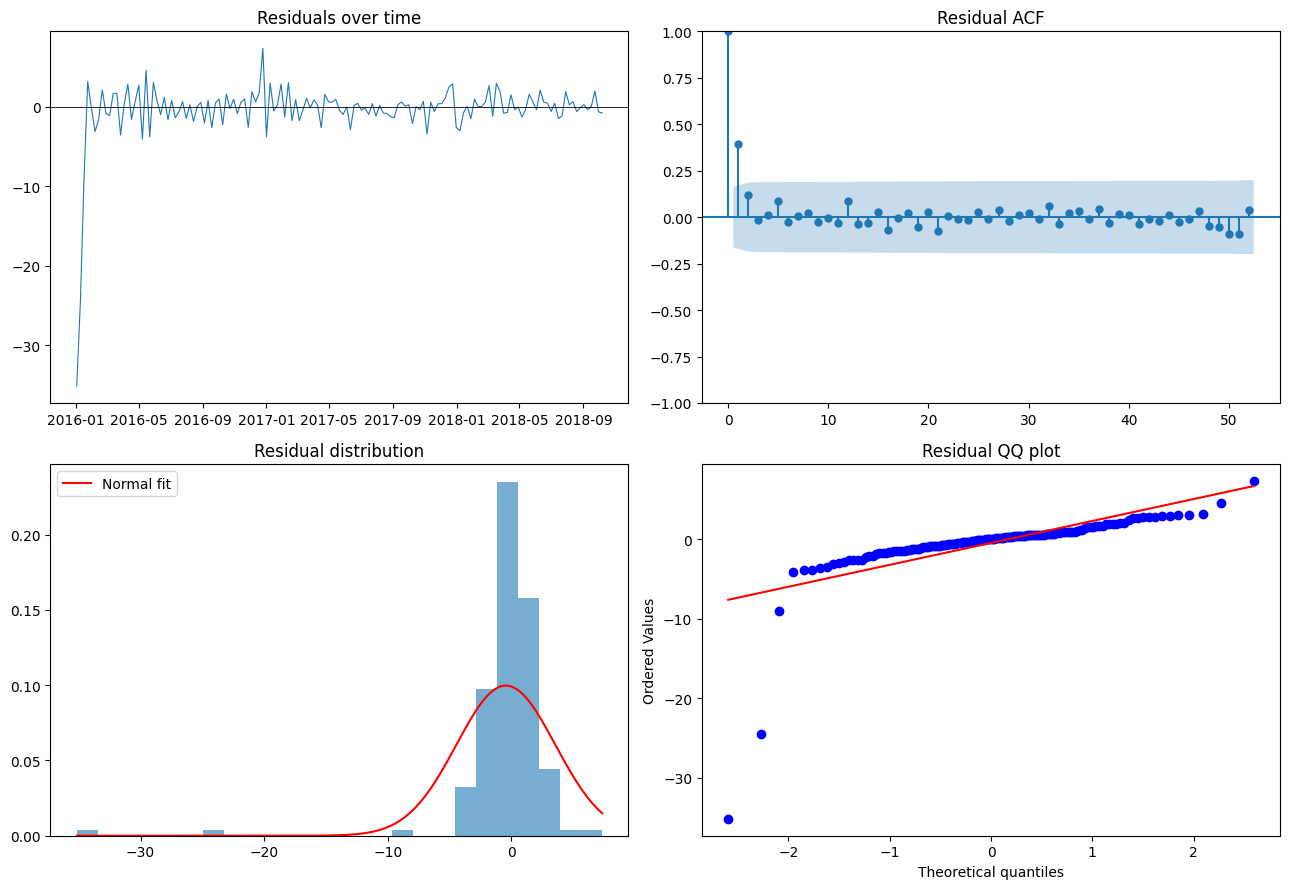

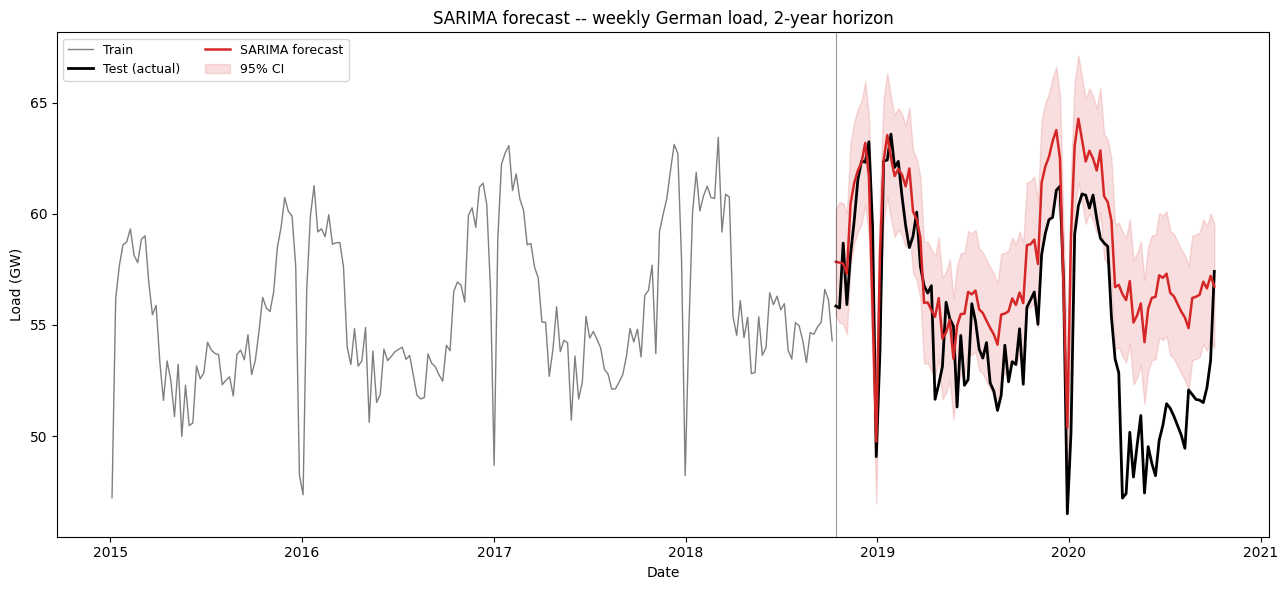

In [16]:
fit, grid, metrics, (mean, ci) = run_part3(weekly, save_dir="outputs/03")